# Conversión de una imagen RGB a escala de grises usando el modo de color YUV

El modo de color YUV representa el color en términos de luminancia (Y) y crominancia (U y V). La componente Y representa la luminosidad de la imagen, mientras que U y V representan la información de color. Al extraer solo la componente Y, podemos convertir una imagen RGB a escala de grises, ya que esta componente contiene toda la información necesaria sobre la intensidad de luz sin los detalles de color.

El componente Y se calcula utilizando una combinación ponderada de las componentes R, G y B de la imagen original. Los valores son obtenidos del estandar ITU‑R BT.601 para la televisión en definición estándar.

La fórmula comúnmente utilizada para calcular Y es:
$$
Y = 0.299 * R + 0.587 * G + 0.114 * B
$$

In [1]:
import sys
import os

# Obtener el directorio padre (ruta base del proyecto)
base_path = os.path.abspath('..')
if base_path not in sys.path:
    sys.path.append(base_path)

import matplotlib.pyplot as plt
import paths, read_img

# Rutas del proyecto
data_dir = paths.data_dir()
avance1_base = paths.fase1_aumento_de_datos_dir()


In [2]:
train_path = os.path.join(data_dir, 'train','images')
image_names = [f for f in os.listdir(train_path) if os.path.isfile(os.path.join(train_path, f))]

# Filtrar solo archivos de imagen
image_extensions = ('.jpg', 'png')
image_names = [f for f in image_names if f.lower().endswith(image_extensions)]

# Seleccionar 5 imágenes
sel_images = image_names[:5]
sel_images_paths = [os.path.join(train_path, name) for name in sel_images]

print("Imágenes originales:")
i = 1
for path in sel_images:
    print(f'- Imagen {i}: {path}')
    i += 1

Imágenes originales:
- Imagen 1: 1300_png.rf.7b332636c8e913a345261bc6ec715680.jpg
- Imagen 2: 1392_png.rf.0cff93c4891cf1412de96ef971310873.jpg
- Imagen 3: 325_JPG.rf.0d24b551ca63f842f5629f94a3a6a229.jpg
- Imagen 4: 60_png.rf.02ba237d0a88e494a6f81cf2f87a1848.jpg
- Imagen 5: 1221_jpg.rf.df87165e9b5c4978791390e2a753e587.jpg


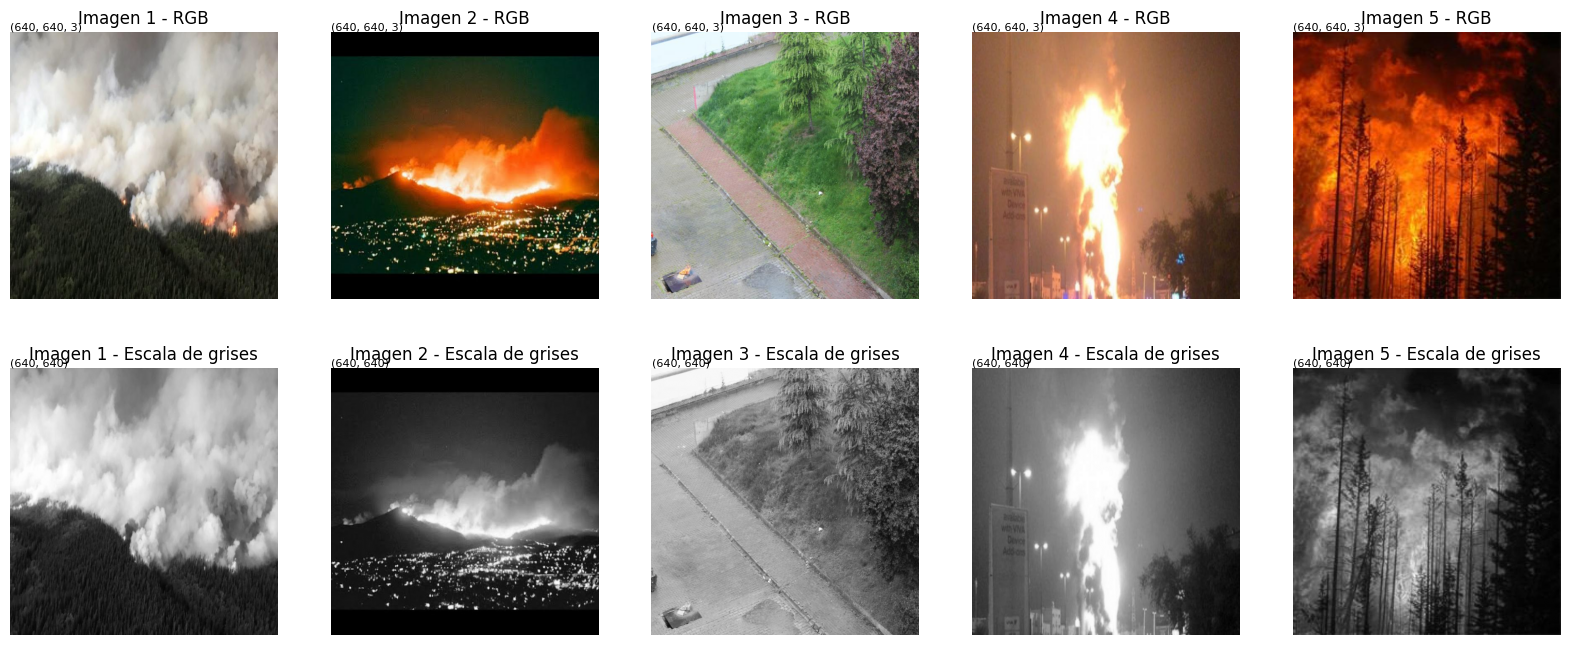

In [3]:
# Mostramos las imágen original en RGB junto a su versión en escala de grises
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, image_path in enumerate(sel_images_paths):
    # Leer imagen en RGB
    img_rgb = read_img.read_image_as_rgb(image_path)
    axs[0, i].imshow(img_rgb)
    axs[0, i].set_title(f'Imagen {i+1} - RGB')
    axs[0, i].text(0, -5, img_rgb.shape, fontsize=8)
    axs[0, i].axis('off')

    # Leer imagen en escala de grises
    img_gray = read_img.read_image_as_grayscale(image_path)
    axs[1, i].imshow(img_gray, cmap='gray')
    axs[1, i].set_title(f'Imagen {i+1} - Escala de grises')
    axs[1, i].text(0, -5, img_gray.shape, fontsize=8)
    axs[1, i].axis('off')